# 第五章 &nbsp; &nbsp; 误差反向传播法
上一章中，我们介绍了神经网络的学习，并通过数值微分计算了神经网络的权重参数的梯度（严格来说，是损失函数关于权重参数的梯度）。数值微分虽然简单，也容易实现，但缺点是计算上比较费时间。本章我们将学习一个能够高效计算权重参数的梯度的方法——误差反向传播法。

要正确理解误差反向传播法，我个人认为有两种方法：一种是基于数学式；另一种是基于计算图（computational graph）。前者是比较常见的方法，机器学习相关的图书中多数都是以数学式为中心展开论述的。因为这种方法严密且简洁，所以确实非常合理，但如果一上来就围绕数学式进行探讨，会忽略一些根本的东西，止步于式子的罗列。因此，本章希望大家通过计算图，直观地理解误差反向传播法。然后，再结合实际的代码加深理解，相信大家一定会有种“原来如此！”的感觉。

## 链式法则
前面介绍的计算图的正向传播将计算结果正向（从左到右）传递，其计算过程是我们日常接触的计算过程，所以感觉上可能比较自然。而反向传播将局部导数向正方向的反方向（从右到左）传递，一开始可能会让人感到困惑。传递这个局部导数的原理，是基于链式法则（chain rule）的。本节将介绍链式法则，并阐明它是如何对应计算图上的反向传播的。

链式法则是关于复合函数的导数的性质，定义如下。

如果某个函数由复合函数表示，则该复合函数的导数可以用构成复合函数的各个函数的导数的乘积表示。

这就是链式法则的原理，乍一看可能比较难理解，但实际上它是一个非常简单的性质。以式(5.1)为例，$\frac{\partial z}{\partial x}$（$z$关于$x$的导数）可以用$\frac{\partial z}{\partial t}$（$z$关于$t$的导数）和$\frac{\partial t}{\partial x}$（$t$关于$x$的导数）的乘积表示。用数学式表示的话，可以写成式(5.2)。

$$
\frac{\partial z}{\partial x} = \frac{\partial z}{\partial t} \frac{\partial t}{\partial x} \tag{5.2}
$$

式(5.2)中的$\partial t$正好可以像下面这样“互相抵消”，所以记起来很简单。

$$
\frac{\partial z}{\partial x} = \frac{\partial z}{\partial \cancel{t}} \frac{\cancel{t}}{\partial x}
$$

现在我们使用链式法则，试着求式(5.2)的导数$\frac{\partial z}{\partial x}$。为此，我们要先求式(5.1)中的局部导数（偏导数）。

$$
\begin{align}
\frac{\partial z}{\partial t} &= 2t \\
\frac{\partial t}{\partial x} &= 1
\end{align} \tag{5.3}
$$

如式(5.3)所示，$\frac{\partial z}{\partial t}$等于$2t$，$\frac{\partial t}{\partial x}$等于1。这是基于导数公式的解析解。然后，最后要计算的$\frac{\partial z}{\partial x}$可由式(5.3)求得的导数的乘积计算出来。

$$
\frac{\partial z}{\partial x} = \frac{\partial z}{\partial t} \frac{\partial t}{\partial x} = 2t \cdot 1 = 2(x + y) \tag{5.4}
$$

## 乘法层的实现
层的实现中有两个共通的方法（接口）``forward()``和``backward()``。``forward()``对应正向传播，``backward()``对应反向传播。现在来实现乘法层。乘法层作为``MulLayer``类，其实现过程如下所示。

<img src="./fig/MulLayer_example.png" alt="乘法层" style="display: block; margin: 0 auto;">

In [1]:
class MulLayer:
    def __init__(self):
        # 乘法层的输入
        self.x = None
        self.y = None

    def forward(self, x, y):
        self.x = x
        self.y = y
        out = x * y

        return out

    def backward(self, dout):
        dx = dout * self.y # 反向传播时，乘以另一个输入
        dy = dout * self.x # 反向传播时，乘以另一个输入

        return dx, dy

# 乘法层的使用示例
apple = 100
apple_num = 2 # 2个苹果
tax = 1.1 # 消费税10%

# 计算总价
mul_apple_layer = MulLayer() # 计算苹果价格的乘法层
mul_tax_layer = MulLayer() # 计算总价的乘法层

# 计算中间值
apple_price = mul_apple_layer.forward(apple, apple_num) # 苹果价格
price = mul_tax_layer.forward(apple_price, tax) # 总价

print(price) # 220.0

# 反向传播
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(dapple, dapple_num, dtax) # (2.2, 110.0, 200.0)

220.00000000000003
2.2 110.00000000000001 200


## 加法层的实现
接下来，我们实现加法节点的加法层，如下所示。

<img src="./fig/AddLayer_example.png" alt="加法层" style="display: block; margin: 0 auto;">

In [2]:
class AddLayer:
    def __init__(self):
        pass # 加法层没有成员变量

    def forward(self, x, y):
        out = x + y
        return out
    
    def backward(self, dout):
        dx = dout * 1
        dy = dout * 1
        return dx, dy

# 加法层的使用示例
apple = 100
apple_num = 2 # 2个苹果
orange = 150
orange_num = 3 # 3个橘子
tax = 1.1 # 消费税10%

# 计算总价
mul_apple_layer = MulLayer() # 计算苹果价格的乘法层
mul_orange_layer = MulLayer() # 计算橘子价格的乘法层
add_apple_orange_layer = AddLayer() # 计算苹果和橘子总价的加法层
mul_tax_layer = MulLayer() # 计算总价的乘法层

# 计算中间值
apple_price = mul_apple_layer.forward(apple, apple_num) # 苹果价格，（1）
orange_price = mul_orange_layer.forward(orange, orange_num) # 橘子价格，（2）
all_price = add_apple_orange_layer.forward(apple_price, orange_price) # 苹果和橘子总价，（3）
price = mul_tax_layer.forward(all_price, tax) # 总价，（4）

print(price) # 715.0

# 反向传播
dprice = 1
dall_price, dtax = mul_tax_layer.backward(dprice)# 反向传播到（4）
dapple_price, dorange_price = add_apple_orange_layer.backward(dall_price) # 反向传播到（3）
dorange, dorange_num =mul_orange_layer.backward(dorange_price) # 反向传播到（2）
dapple, dapple_num = mul_apple_layer.backward(dapple_price) # 反向传播到（1）

print(dapple, dapple_num, dorange, dorange_num, dtax) # (2.2, 110.0, 3.3, 165.0, 650.0)

715.0000000000001
2.2 110.00000000000001 3.3000000000000003 165.0 650


这个实现稍微有一点长，但是每一条命令都很简单。首先，生成必要的层，以合适的顺序调用正向传播的forward()方法。然后，用与正向传播相反的顺序调用反向传播的``backward()``方法，就可以求出想要的导数。

综上，计算图中层的实现（这里是加法层和乘法层）非常简单，使用这些层可以进行复杂的导数计算。下面，我们来实现神经网络中使用的层。

## ReLU层
激活函数ReLU(Rectified Linear Unit)由下式(5.7)表示。

$$
y = \begin{cases}
x & (x > 0) \\
0 & (x \leqslant 0)
\end{cases} \tag{5.7}
$$

通过式(5.7)，可以求出$y$关于$x$的导数，如式(5.8)所示。

$$
\frac{\partial y}{\partial x} = \begin{cases}
1 & (x > 0) \\
0 & (x \leqslant 0)
\end{cases} \tag{5.8}
$$

在式(5.8)中，如果正向传播时的输入$x$大于0，则反向传播会将上游的值原封不动地传给下游。反过来，如果正向传播时的$x$小于等于0，则反向传播中传给下游的信号将停在此处。用计算图表示的话，如图所示。

现在我们来实现ReLU层。在神经网络的层的实现中，一般假定`forward()`和`backward()`的参数是NumPy数组。

<img src="./fig/ReLU.png" alt="relu层" style="display: block; margin: 0 auto;">

In [3]:
class Relu:
    def __init__(self):
        self.mask = None # 记录输入值小于等于0的位置

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy() # 复制输入值
        out[self.mask] = 0 # 将小于等于0的值置为0

        return out
    
    def backward(self, dout):
        dout[self.mask] = 0 # 将小于等于0的位置的梯度置为0
        dx = dout

        return dx 
    
# ReLU层的使用示例
import numpy as np
x = np.array([[1.0, -0.5], [-2.0, 3.0]])
print(x)
mask = (x <= 0)
print(mask)
relu_layer = Relu()
out = relu_layer.forward(x)
print(out)# [[1. 0.] [0. 3.]]
dout = np.array([[1.0, 1.0], [1.0, 1.0]])# 上游传下来的梯度
dx = relu_layer.backward(dout)
print(dx)# [[1. 0.] [0. 1.]]

[[ 1.  -0.5]
 [-2.   3. ]]
[[False  True]
 [ True False]]
[[1. 0.]
 [0. 3.]]
[[1. 0.]
 [0. 1.]]


## Sigmoid层
接下来，我们来实现sigmoid函数。sigmoid函数由式(5.9)表示。

$$
y = \frac{1}{1 + \exp(-x)} \tag{5.9}
$$

用计算图表示式(5.9)的话，则如图所示。

<img src="./fig/sigmoid.png" alt="sigmoid层" style="display: block; margin: 0 auto;">

另外，$\frac{\partial L}{\partial y} y^2 \exp(-x)$可以进一步整理如下。

$$
\begin{align}
\frac{\partial L}{\partial y} y^2 \exp(-x) &= \frac{\partial L}{\partial y} \frac{1}{(1 + \exp(-x))^2} \exp(-x) \\
&= \frac{\partial L}{\partial y} \frac{1}{1 + \exp(-x)} \frac{\exp(-x)}{1 + \exp(-x)} \\
&= \frac{\partial L}{\partial y} y(1 - y)
\end{align} \tag{5.12}
$$

In [4]:
class Sigmoid:
    def __init__(self):
        self.out = None # sigmoid的输出值

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        
        return out
    
    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out # sigmoid函数的导数
        
        return dx

## Affine层
现在我们来考虑计算图的反向传播。以矩阵为对象的反向传播，按矩阵的各个元素进行计算时，步骤和以标量为对象的计算图相同。实际写一下的话，可以得到下式（这里省略了式(5.13)的推导过程）。

$$
\begin{align}
\frac{\partial L}{\partial \boldsymbol{X}} &= \frac{\partial L}{\partial \boldsymbol{Y}} \cdot \boldsymbol{W}^{\mathrm{T}} \\
\frac{\partial L}{\partial \boldsymbol{W}} &= \boldsymbol{X}^{\mathrm{T}} \cdot \frac{\partial L}{\partial \boldsymbol{Y}}
\end{align} \tag{5.13}
$$

式(5.13)中$\boldsymbol{W}^{\mathrm{T}}$的T表示转置。转置操作会把$\boldsymbol{W}$的元素$(i, j)$换成元素$(j, i)$。用数学式表示的话，可以写成下面这样。

$$
\begin{align}
\boldsymbol{W} &= \begin{pmatrix}
w_{11} & w_{12} & w_{13} \\
w_{21} & w_{22} & w_{23}
\end{pmatrix} \\
\boldsymbol{W}^{\mathrm{T}} &= \begin{pmatrix}
w_{11} & w_{21} \\
w_{12} & w_{22} \\
w_{13} & w_{23}
\end{pmatrix}
\end{align} \tag{5.14}
$$

<img src="./fig/affine_layer.png" alt="affine层" style="display: block; margin: 0 auto;">

In [5]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b
        self.x = None  # 输入值
        self.dW = None # 权重的梯度
        self.db = None # 偏置的梯度

    def forward(self, x):
        self.x = x
        out = np.dot(x, self.W) + self.b

        return out
    
    def backward(self, dout):
        dx = np.dot(dout, self.W.T) # 计算输入值的梯度，self.W.T是权重矩阵的转置
        self.dW = np.dot(self.x.T, dout) # 计算权重的梯度
        self.db = np.sum(dout, axis=0) # 计算偏置的梯度，axis=0表示对行求和

        return dx

## Softmax-with-loss层

<img src="./fig/softmax-with-loss.png" alt="softmax-with-loss层" style="display: block; margin: 0 auto;">

神经网络中进行的处理有推理（inference）和学习两个阶段。神经网络的推理通常不使用 Softmax层。比如，用上图的网络进行推理时，会将最后一个 Affine层的输出作为识别结果。神经网络中未被正规化的输出结果（图中Softmax层前面的 Affine层的输出）有时被称为“得分”。也就是说，当神经网络的推理只需要给出一个答案的情况下，因为此时只对得分最大值感兴趣，所以不需要 Softmax层。不过，神经网络的学习阶段则需要 Softmax层。

<img src="./fig/softmax-with-loss_layer.png" alt="softmax-with-loss层" style="display: block; margin: 0 auto;">

使用交叉熵误差作为softmax函数的损失函数后，反向传播得到$(y_1 - t_1, y_2 - t_2, y_3 - t_3)$这样“漂亮”的结果。实际上，这样“漂亮”的结果并不是偶然的，而是为了得到这样的结果，特意设计了交叉熵误差函数。回归问题中输出层使用“恒等函数”，损失函数使用“平方和误差”，也是出于同样的理由（3.5节）。也就是说，使用“平方和误差”作为“恒等函数”的损失函数，反向传播才能得到$(y_1 - t_1, y_2 - t_2, y_3 - t_3)$这样“漂亮”的结果。

In [6]:
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而
from common.functions import softmax, cross_entropy_error
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None # 损失
        self.y = None    # softmax的输出值
        self.t = None    # 监督数据（one-hot vector）

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss
    
    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        dx = (self.y - self.t) / batch_size # 计算输入值的梯度

        return dx 



## 神经网络学习的全貌图
在进行具体的实现之前，我们再来确认一下神经网络学习的全貌图。神经网络学习的步骤如下所示。

### 前提
神经网络中有合适的权重和偏置，调整权重和偏置以便拟合训练数据的过程称为学习。神经网络的学习分为下面4个步骤。

### 步骤1（mini-batch）
从训练数据中随机选择一部分数据。

### 步骤2（计算梯度）
计算损失函数关于各个权重参数的梯度。

### 步骤3（更新参数）
将权重参数沿梯度方向进行微小的更新。

### 步骤4（重复）
重复步骤1、步骤2、步骤3。

### 表5-1 TwoLayerNet类的实例变量

| 实例变量   | 说明                                                                 |
|------------|----------------------------------------------------------------------|
| params     | 保存神经网络的参数的字典型变量。<br>params['W1']是第1层的权重，params['b1']是第1层的偏置。<br>params['W2']是第2层的权重，params['b2']是第2层的偏置 |
| layers     | 保存神经网络的层的有序字典型变量。<br>以layers['Affine1']、layers['Relu1']、layers['Affine2']的形式，<br>通过有序字典保存各个层 |
| lastLayer  | 神经网络的最后一层。<br>本例中为SoftmaxWithLoss层                     |

### 表5-2 TwoLayerNet类的方法

| 方法                                  | 说明                                                                 |
|---------------------------------------|----------------------------------------------------------------------|
| \_\_init\_\_(self, input_size, hidden_size, output_size, weight_init_std) | 进行初始化。<br>参数从头开始依次是输入层的神经元数、隐藏层的<br>神经元数、输出层的神经元数、初始化权重时的高<br>斯分布的规模 |
| predict(self, x)                      | 进行识别（推理）。<br>参数x是图像数据                                 |
| loss(self, x, t)                      | 计算损失函数的值。<br>参数x是图像数据、t是正确解标签                  |
| accuracy(self, x, t)                  | 计算识别精度                                                         |
| numerical_gradient(self, x, t)        | 通过数值微分计算关于权重参数的梯度（同上一章）|
| gradient(self, x, t)                  | 通过误差反向传播法计算关于权重参数的梯度                             |

In [7]:
import sys,os
sys.path.append(os.pardir) # 为了导入父目录的文件而进行的设定
import numpy as np
from common.layers import *
from common.gradient import numerical_gradient
from collections import OrderedDict # 维护元素插入顺序的字典

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 初始化权重
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

        # 生成层
        self.layers = OrderedDict() # 维护元素插入顺序的字典，便于按顺序进行前向传播和反向传播
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu1'] = Relu() # 激活函数
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])
        self.lastLayer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values(): # 遍历所有层
            x = layer.forward(x) # 按顺序进行前向传播

        return x
    
    # x: 输入数据, t: 监督数据
    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
    # x: 输入数据, t: 监督数据
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads
    
    def gradient(self, x, t):
        # forward
        self.loss(x, t) 

        # backward
        dout = 1
        dout = self.lastLayer.backward(dout) # 反向传播到最后一层

        layers = list(self.layers.values()) # 获取所有层
        layers.reverse() # 反转层的顺序，便于反向传播
        # 反向传播
        for layer in layers:
            dout = layer.backward(dout)
        
        # 设定梯度
        grads = {}
        grads['W1'] = self.layers['Affine1'].dW
        grads['b1'] = self.layers['Affine1'].db
        grads['W2'] = self.layers['Affine2'].dW
        grads['b2'] = self.layers['Affine2'].db

        return grads

## 误差反向传播法的梯度确认
到目前为止，我们介绍了两种求梯度的方法。一种是基于数值微分的方法，另一种是解析性地求解数学式的方法。后一种方法通过使用误差反向传播法，即使存在大量的参数，也可以高效地计算梯度。因此，后文将不再使用耗费时间的数值微分，而是使用误差反向传播法求梯度。

数值微分的计算很耗费时间，而且如果有误差反向传播法的（正确的）实现的话，就没有必要使用数值微分的实现了。那么数值微分有什么用呢？实际上，在确认误差反向传播法的实现是否正确时，是需要用到数值微分的。

数值微分的优点是实现简单，因此，一般情况下不太容易出错。而误差反向传播法的实现很复杂，容易出错。所以，经常会比较数值微分的结果和误差反向传播法的结果，以确认误差反向传播法的实现是否正确。确认数值微分求出的梯度结果和误差反向传播法求出的结果是否一致（严格地讲，是非常相近）的操作称为梯度确认（gradient check）。梯度确认的代码实现如下所示。

In [8]:
import sys,os
sys.path.append(os.pardir) # 为了导入父目录的文件而进行
import numpy as np
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet

# 读取MNIST数据集
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

x_batch = x_train[:3] # 取训练数据的前3个样本
t_batch = t_train[:3] # 取监督数据的前3个样本

# 计算数值梯度
grad_numerical = network.numerical_gradient(x_batch, t_batch)
# 计算误差反向传播法的梯度
grad_backprop = network.gradient(x_batch, t_batch)

# 比较两种方法计算的梯度
for key in grad_numerical.keys():
    diff = np.average( np.abs(grad_backprop[key] - grad_numerical[key]) )
    print(key + ":" + str(diff)) # 误差很小，说明误差反向传播法的实现是正确的


W1:1.963308547920734e-10
b1:1.0468523558664734e-09
W2:6.864008434993852e-08
b2:1.380081418769774e-07


从这个结果可以看出，通过数值微分和误差反向传播法求出的梯度的差非常小。这样一来，我们就知道了通过误差反向传播法求出的梯度是正确的，误差反向传播法的实现没有错误。

## 使用误差反向传播法的学习
最后，我们来看一下使用了误差反向传播法的神经网络的学习的实现。和之前的实现相比，不同之处仅在于通过误差反向传播法求梯度这一点。

Epoch 0 | 训练准确率: 0.0987 | 测试准确率: 0.0980
Epoch 1 | 训练准确率: 0.8049 | 测试准确率: 0.8099
Epoch 2 | 训练准确率: 0.8800 | 测试准确率: 0.8826
Epoch 3 | 训练准确率: 0.9005 | 测试准确率: 0.9024
Epoch 4 | 训练准确率: 0.9086 | 测试准确率: 0.9105
Epoch 5 | 训练准确率: 0.9136 | 测试准确率: 0.9182
Epoch 6 | 训练准确率: 0.9193 | 测试准确率: 0.9220
Epoch 7 | 训练准确率: 0.9232 | 测试准确率: 0.9251
Epoch 8 | 训练准确率: 0.9268 | 测试准确率: 0.9289
Epoch 9 | 训练准确率: 0.9303 | 测试准确率: 0.9323
Epoch 10 | 训练准确率: 0.9331 | 测试准确率: 0.9343
Epoch 11 | 训练准确率: 0.9349 | 测试准确率: 0.9370
Epoch 12 | 训练准确率: 0.9378 | 测试准确率: 0.9387
Epoch 13 | 训练准确率: 0.9404 | 测试准确率: 0.9413
Epoch 14 | 训练准确率: 0.9426 | 测试准确率: 0.9419
Epoch 15 | 训练准确率: 0.9446 | 测试准确率: 0.9451
Epoch 16 | 训练准确率: 0.9464 | 测试准确率: 0.9447


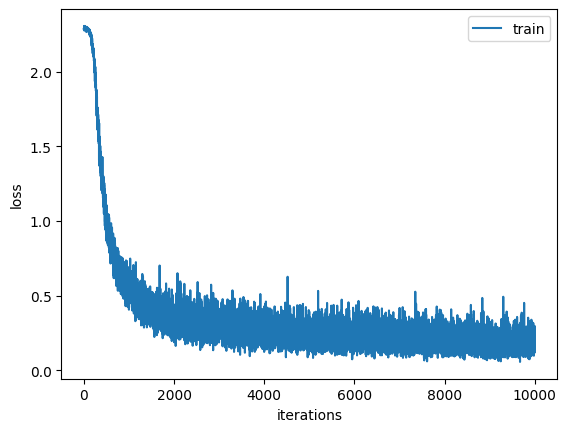

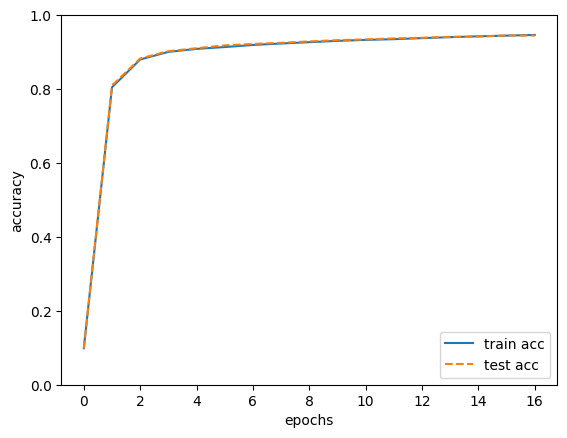

In [9]:
import sys,os
sys.path.append(os.pardir) # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet

# 读取MNIST数据集
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iters_num = 10000 # 迭代次数
train_size = x_train.shape[0]
batch_size = 100 # 批量大小
learning_rate = 0.1 # 学习率
train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    # 获取mini-batch
    batch_mask = np.random.choice(train_size, batch_size) # 随机选择batch_size个样本
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 通过误差反向传播法计算梯度
    grad = network.gradient(x_batch, t_batch)

    # 更新参数
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 记录学习过程
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        # 计算当前 epoch 数
        epoch = i // iter_per_epoch
        # 格式化输出，保留4位小数并显示 epoch 信息
        print(f"Epoch {int(epoch)} | 训练准确率: {train_acc:.4f} | 测试准确率: {test_acc:.4f}")

# 绘制图像
plt.plot(train_loss_list,label="train")
plt.xlabel("iterations")
plt.ylabel("loss")
plt.legend()
plt.show()

# 绘制准确率曲线
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')#显示图例，位置在右下角
plt.show()

## 小结
- 通过使用计算图，可以直观地把握计算过程。
- 计算图的节点是由局部计算构成的。局部计算构成全局计算。
- 计算图的正向传播进行一般的计算。通过计算图的反向传播，可以计算各个节点的导数。
- 通过将神经网络的组成元素实现为层，可以高效地计算梯度（反向传播法）。
- 通过比较数值微分和误差反向传播法的结果，可以确认误差反向传播法的实现是否正确（梯度确认）。